In [1]:
import matplotlib.pyplot as plt
import polars as pl

import cartopy.crs as ccrs
import cartopy.feature

from matplotlib.colors import LinearSegmentedColormap

In [2]:
df = pl.read_parquet("Simulations/Simulation_Satellite_kN_0.001.parquet")

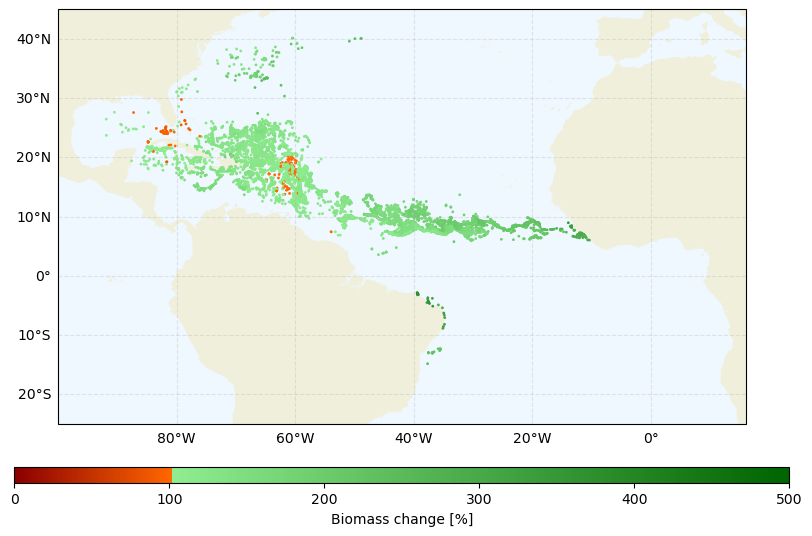

In [ ]:
fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor('aliceblue')
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

last_time = df.select(pl.col("time").max()).item()
last_locations = df.filter(pl.col("time") == last_time)
not_stranded = last_locations.filter(pl.col("stranded") == False)

cmap = LinearSegmentedColormap.from_list(
    'red_orange_green',
    [(0.0, '#8b0000'), (0.2, '#ff6600'), (0.2, '#90ee90'), (1.0, '#006400')]
)

cscat = ax.scatter(
    not_stranded['lon'],
    not_stranded['lat'],
    c=not_stranded['biomass'] * 100,
    s=4,
    linewidth=0,
    cmap=cmap,
    vmin=0,
    vmax=500,
    transform=ccrs.PlateCarree(),
    zorder=1
)

ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.set_extent([-100, 16, -25, 45], crs=ccrs.PlateCarree())

cbar = plt.colorbar(cscat, ax=ax, orientation='horizontal', pad=0.08, aspect=50, label='Biomass change [%]')

fig.savefig('Figures/Figure5.png', bbox_inches='tight', dpi=300)

plt.show()

In [4]:
print(f"Particle-averaged biomass change: {not_stranded['biomass'].mean() * 100:.0f}%")

Particle-averaged biomass change: 145%


In [5]:
print(f"Percentage of particles that have biomass change < 100%: {(not_stranded['biomass'] * 100 < 100).sum() / not_stranded.shape[0] * 100:.1f}%")

Percentage of particles that have biomass change < 100%: 1.4%
